1. DFS Templae
   DFS explores a graph by dividing deep from each node, marking nodes as 
   visited so it doesn't loop forever. The recursive version is always this 
   shape:

```Python
visited = [0, 0, ..., 0]        # global, start unvisited

def Explore(u):
    visited[u] = 1          # (A) mark current node
    for v in neighbours_of(u):
        if edge_exists AND visited[v] == 0:     # (B) Only visit unseen
            Explore(v)                          # (C) recurse into neighbour
```
   
   Three things always happen in order: MARK -> CHECK -> RECURSE.
   * MARK YOURSELF FIRST so if a recursive call comes back to you, it knows to
     skip.
   * CHECK EACH NEIGHBOUR -- only unseen ones.
   * RECURSE into each valid neighbour.

   For an adjacncy matrix representation, "neighbours of u"  becomes
   `for v = 1 to n: if A[u][v] == 1`. Same idea, different lookup.


---

### Question 1: DFS Reachability Completion [Based on 2024 Q1]

You are given a directed graph represented by an $n \times n$ adjacency matrix A, where A[u][v] == 1 means there is an edge from $u$ to $v$. You want to find all nodes reachable from a starting node s. Fill in the blanks (1), (2), and (3) in the recursive Depth-First Search pseudocode below.

In [ ]:
# Global array to track visited nodes, initially all 0
visited = [0, 0, ..., 0] 

def Explore(u):
    visited[u] = 1
    
    for v = 1 to n:
        # If there is an edge to v, AND v has not been visited yet
        if A[u][v] == 1 and visited[n] == 0:
            # Recursively explore from the neighbour
            Explore(v)

# To start the search:
Explore(s)

---

---

### 2. 1D DP Template
   Recall the four steps:
   1. State: `dp[i]` = the best answer for problem size i. Here: minimum coins 
      to make value i.
   2. BASE CASE: the trivially-known smallest subproblem. For coin change: 
      `dp[0] = 0` (zero coins needed to make zero value). Everything else
      starts as `infinity` (unknown / unreachable).   
   3. RECURRENCE: for each i from 1 to V, try every coin. "If I use a coin of
      size `coins[j]`, I still need to make `i - coins[j]`, which I've already
      solved." So:

      `dp[i] = min(dp[i], 1 + dp[i - coins[j]])`

   The `1 + ...` accounts for the coin we just used. We take `min` because we 
   want the fewest coins. 4. ANSWER: `dp[V]` -- the cell whose parameter matches
   the origiinal question.

   The loop order matters: outer loop over `i` (smaller to larger), inner loop
   over the choices (which coin). By the time you compute

---

### Question 2: DP Coin Change (Minimization) [Based on 2025 Q1]
You are given an array of coin denominations coins[1...k] and a target value $V$. You want to find the minimum number of coins needed to make exactly $V$. The array dp[0...V] will store the minimum coins needed for every value up to $V$. Fill in the blanks (1), (2), and (3).

In [ ]:
# Initialization
dp[0] = 0
for i = 1 to V:
    dp[i] = infinity

# Table filling
for i = 1 to V:
    for j = 1 to k:
        # If the coin is small enough to be used for the current value i
        if coins[j] <= i:
            # Update the dp table
            dp[i] = minimum(dp[i], 1 + dp[i - coins[j]])

# The final answer
return dp[V]

---

---

### Question 3: 2D Grid DP Template (Max Path Sum)
   State: `dp[i][j]` = best value accumulated reaching cell (i, j). You can only
   move right or down, so the only cells that can "reach" (i, j) are 
   (i-1, j) (from above) and (i, j-1) (from the left). 

   BASE CASE: `dp[1][1] = G[1][1]` -- the starting cell's value is just itself.

   BOUNDARY CASES:
      - FIRST ROW: only reachable from the left.
         `dp[1][j] = dp[1][j-1] + G[i][j]`
      - FIRST COLUMN: only reachable from above.
         `dp[i][1] = dp[i-1][1] + G[i][1]`
   
   INTERIOR CELLS:
      `dp[i][j] = G[i][j] + max(dp[i-1][j], dp[i][j-1])`

   (Use `max` because we want the largest sum. If it were minimum path sum, use
   `min`.)

   ANSWER: `dp[n][m]` - the bottom-right cell

   FILL ORDER: row by row, left to right. By the time you fill `dp[i][j]`, both
   `dp[i-1][j]` and `dp[i][j-1]` are already done.

---

### Question 3: DP Grid Path (Maximization) [Based on 2023 Q1]
You are given an $n \times m$ grid G filled with positive numbers. You start at the top-left corner (1,1) and want to reach the bottom-right corner (n,m). You can only move Right or Down. The array dp[i][j] will store the maximum sum you can accumulate to reach cell (i,j). Fill in (1), (2), and (3).

# Initialize the starting cell
dp[1][1] = G[1][1]

# Fill the first row (can only arrive from the left)
for j = 2 to m:
    dp[1][j] = dp[1][j-1] + G[1][j]

# Fill the first column (can only arrive from above)
for i = 2 to n:
    dp[i][1] = dp[i-1][1] + G[i][1]

# Fill the rest of the grid
for i = 2 to n:
    for j = 2 to m:
        # Add the current cell's value to the best of the two possible previous cells
        dp[i][j] = G[i][j] + max(dp[i-1][j], dp[i][j-1])

---

---

### Question 1: BFS Shortest Path [Based on 2022 Q1]
You are given an unweighted directed graph represented by an $n \times n$ adjacency matrix A. You want to compute the shortest path distance from a starting node s to all other nodes. A queue Q is used. Fill in the blanks (1), (2), and (3).

In [ ]:
# Initialize distances to infinity
for i = 1 to n: 
    dist[i] = infinity

dist[s] = 0
Q.enqueue(s)

while not Q.isEmpty():
    u = Q.dequeue()
    for v = 1 to n:
        # If there is an edge and v has not been visited
        if A[u][v] == 1 and dist[v] == infinity:
            dist[v] = 1 + dist[u]    # The distance is 1 step further than the parent node
            Q.enqueue(v)

---

### Question 2: DP Longest Common Subsequence [Based on 2021 Q1]
You are given two strings, X of length $n$ and Y of length $m$. You want to find the length of their longest common subsequence. dp[i][j] stores the LCS length of the prefixes X[1..i] and Y[1..j]. Fill in (1) and (2).

In [ ]:
# Base cases: matching with an empty string yields length 0
for i = 0 to n: dp[i][0] = 0
for j = 0 to m: dp[0][j] = 0

for i = 1 to n:
    for j = 1 to m:
        if X[i] == Y[j]:
            dp[i][j] = dp[i-1][j-1] + 1  # (1)
        else:
            dp[i][j] = max(dp[i-1][j], dp[i][j-1])  # (2)

return dp[n][m]

-- A subsequence of a string is a new string generated by deleting zero or more
   characters from the original string without changing the relative order of
   the remaining characters. Unlike substrings, subsequences do not need to be
   contiguous (adjcent) in the original string.


-- 

---

   This problem is about the LONGEST COMMON SUBSEQUENCE (LCS), a classic
   Dynamic Programming (DP) challenge. The goal is to find the longest sequence
   of characters that appear in both strings in the same relative order (but
   not necessarily consecutively).


1. THE CORE IDEA: $i$ and $j$
   We build a 2D grid where `dp[i][j]` represents the answer for the first $i$
   characters of string    

THE LCS Logic Recap
   1. If characters MATCH, look DIAGONALLY TOP-LEFT and add 1.
   2. If they DON'T MATCH, take the MAXIMUM of the cell ABOVE or the cell to
      the LEFT.


THE FINAL DP TABLE
   ... the rows correspond to characters of $X$, and columns correspond to the 
   characters of $Y$

 ,∅,B,D,C,A,B,A
∅,0,0,0,0,0,0,0
A,0,0,0,0,1,1,1
B,0,1,1,1,1,2,2
C,0,1,1,2,2,2,2
B,0,1,1,2,2,3,3
D,0,1,2,2,2,3,3
A,0,1,2,2,3,3,4
B,0,1,2,2,3,4,4

   How to read this table:
   - BASE CASES: The first row and column are all `0` because an empty string
     sharing characters with anything results in an LCS of length 0.
   - A MATCH EXAMPLE: Look at row `A` and column `A`. At `dp[1][4]`, the 
     characters match. We look at `dp[0][3]` (which is 0) and add 1. So,
     `dp[1][4] = 1`.
   - A NON-MATCH EXAMPLE: Look at row `B` (row 2)  and column D (col 2). They
     don't match. We take `max(dp[1][1], dp[2][1])`. Since `dp[2][1]` is 1 and
     `dp[1][2]` is 0, we take 1.
   - THE FINAL ANSWER: The value at the very bottom-rifht corner (`dp[7][6]`) is
     4. This tells us the longest common subsequence between these two strings
     is 4 characters long (e.g., "BDAB" or "BCAB")  

1. Why Diagonal? (The Match)
    Imagine your strings are X = "ABC" and Y = "XYC".
    Both end in C. Because they match, C is definitely part of your longest common subsequence. We "lock it in" (which gives us our + 1).

    Now that we've matched the Cs, we are done with them. We must cross them out and find the longest common subsequence of whatever is left: X = "AB" and Y = "XY".

    By chopping a letter off X, we moved Up 1 Row.

    By chopping a letter off Y, we moved Left 1 Column.

    Moving Up 1 and Left 1 at the same time is exactly moving Diagonally Top-Left.

2. Why Top or Left? (The Mismatch)
    Imagine your strings are X = "ABC" and Y = "XYZ".
    They end in C and Z. They do not match. Since they are different, they cannot both be the last letter of our common subsequence. One of them is useless right now, but we don't know which one. So, we test both alternate realities:

    Reality 1 (Throw away C): We chop the last letter off X and compare "AB" to "XYZ". In the grid, chopping from X means moving Up 1 Row.

    Reality 2 (Throw away Z): We chop the last letter off Y and compare "ABC" to "XY". In the grid, chopping from Y means moving Left 1 Column.

    We calculate both realities and simply take the max() of the two. We don't add +1 because we didn't find a matching pair.

3. How to Extract the Answer (Traceback)
    The DP table only gives you the number (the length of the sequence). To get the actual letters, you have to put yourself at the finish line (the bottom-right cell) and walk backwards to the start, following these rules:

    Look at the characters for your current row and column. Do they match?

    YES: Write this letter down! This is part of your answer. Then, move Diagonally Top-Left to continue.

    NO: You must move to the cell that gave you your current score. Look at the cell directly Above and directly Left. Move into whichever cell has the bigger number. (If there is a tie, you can pick either; it just means there are multiple valid sequences).

    Repeat until you hit a row or column of 0s.

    Since you walked backwards from the end, read the letters you wrote down in reverse.

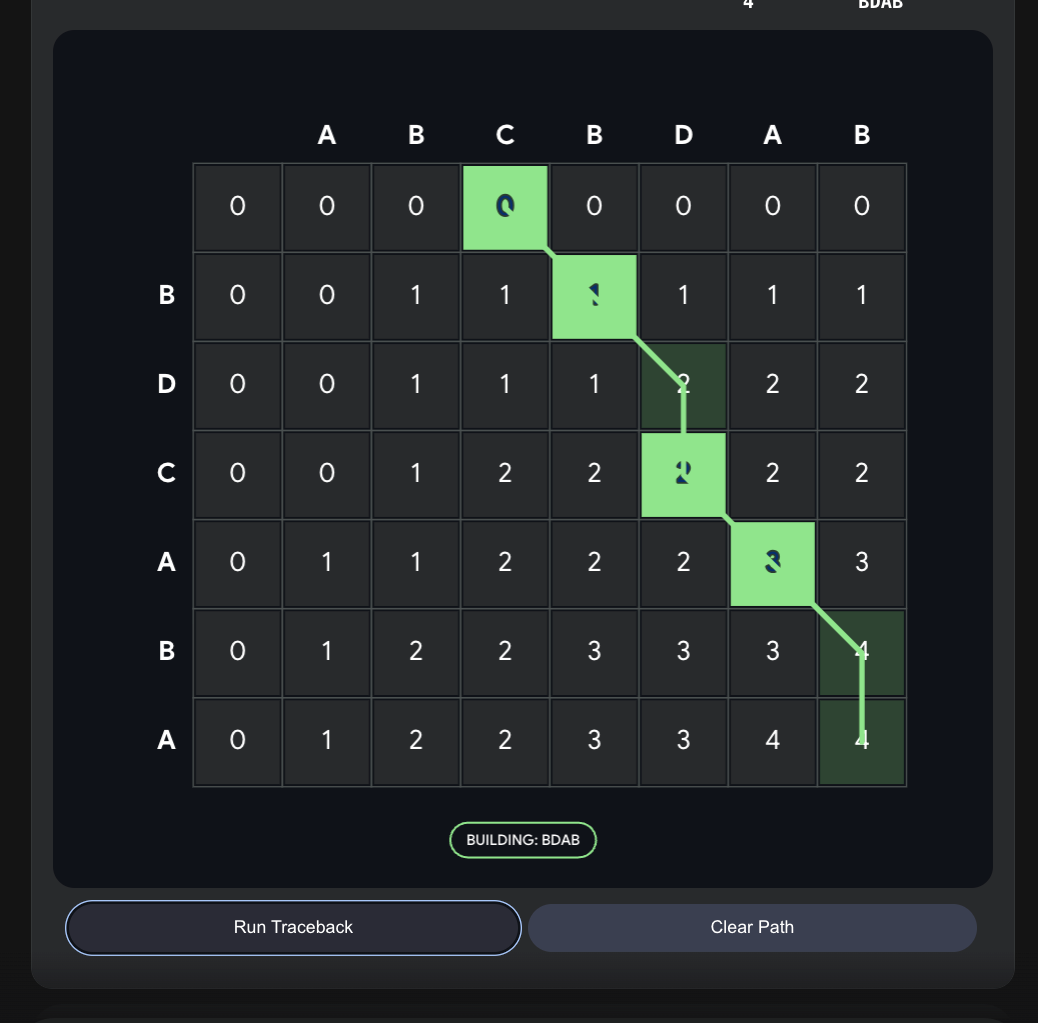